[dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from UCI repo

In [81]:
import pandas as pd
import numpy as np
from scipy.io import arff
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [82]:
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/wine+quality/winequality-red.csv",sep=';')

# arff dataset load
file_path = '/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/bank-additional-ful-nominal.arff'

try:
    data, meta_data = arff.loadarff(file_path)
    data = pd.DataFrame(data)
    for col in data.select_dtypes(['object']).columns: # 2진수 decode 필수
        data[col] = data[col].str.decode('utf-8')

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(e)

In [83]:
print("data 갯수 :\t",len(data))
print("feature 갯수 :\t", len(data.columns))
data.head()

data 갯수 :	 1599
feature 갯수 :	 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [84]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [85]:
# for heart disease data
# wine quality score for 0 to 10
print(data['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [86]:
# 데이터 전처리
data_modi = data.copy()
data_modi.loc[data['quality'] <= 6,'quality'] = 0
data_modi.loc[data['quality'] > 6,'quality'] = 1


target = data_modi['quality']
print(target.value_counts())

quality
0    1382
1     217
Name: count, dtype: int64


<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

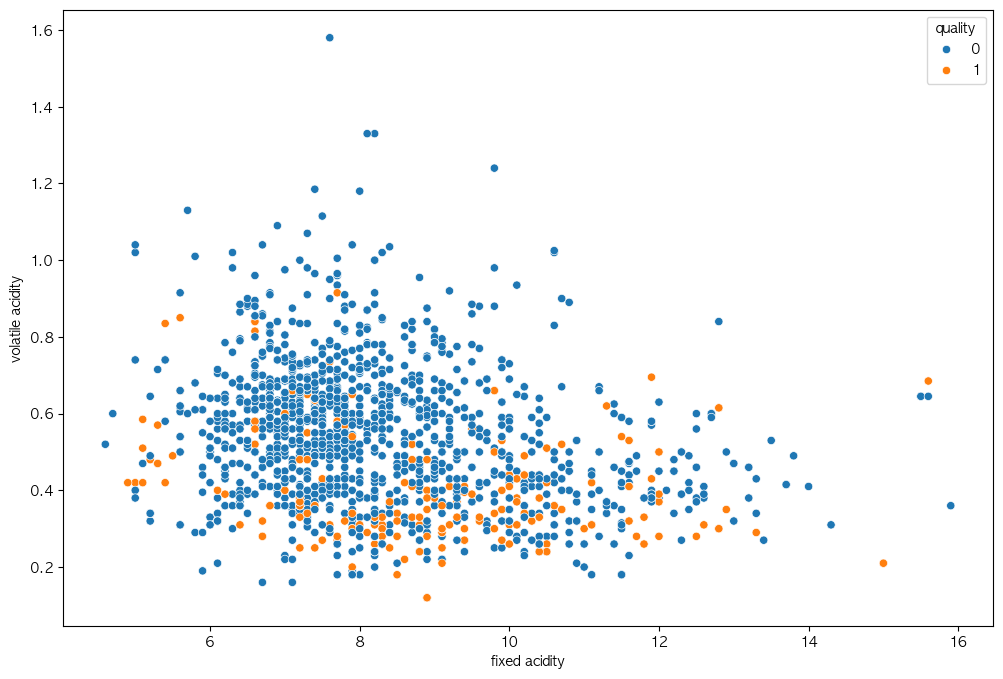

In [87]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue='quality', data=data_modi)

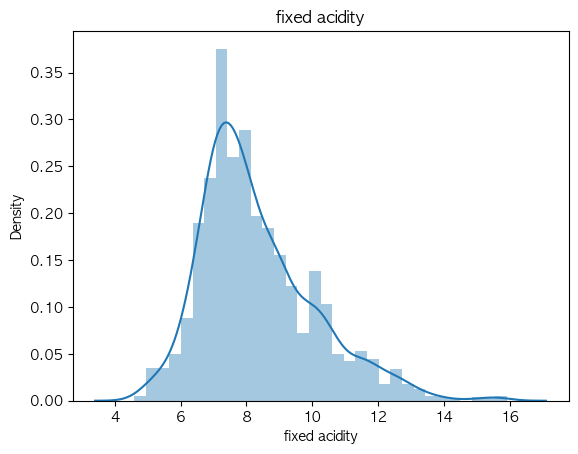

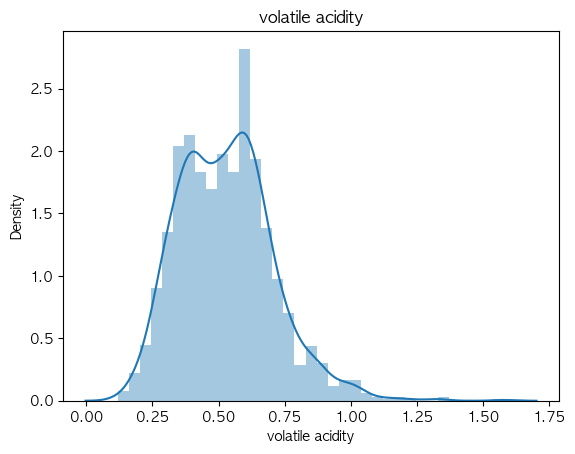

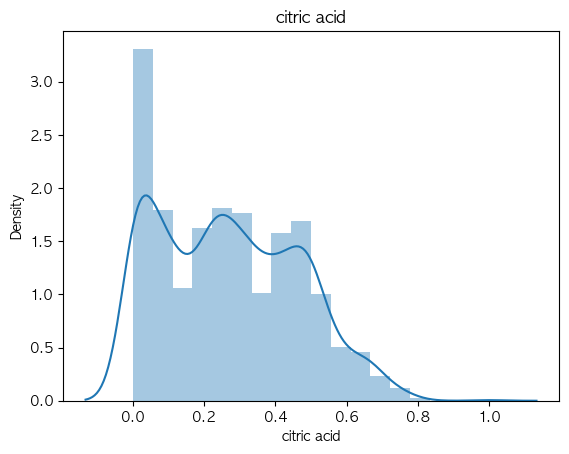

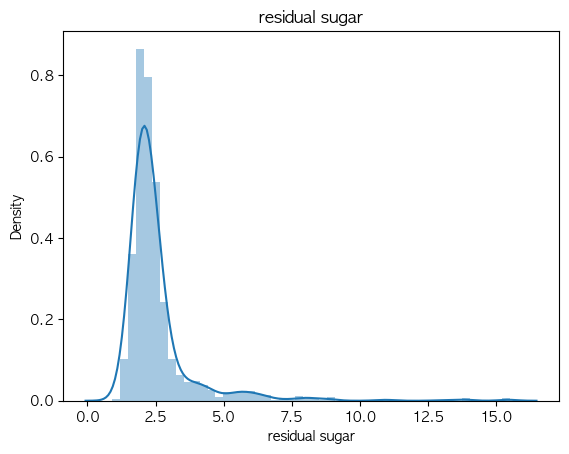

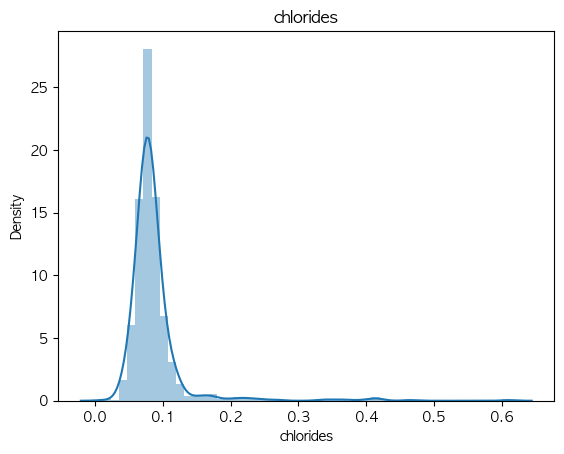

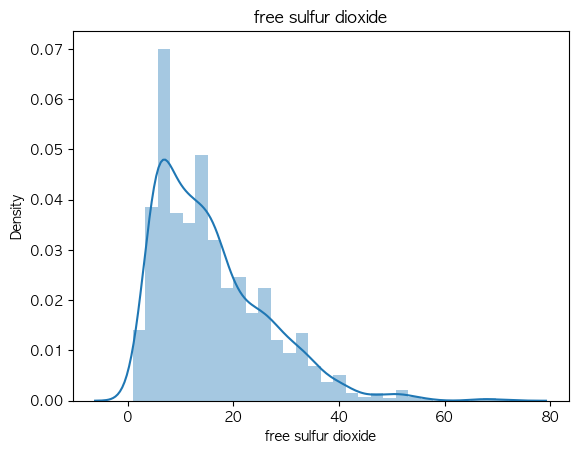

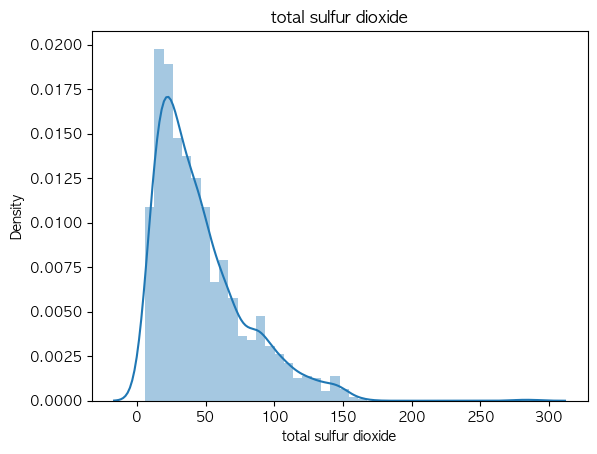

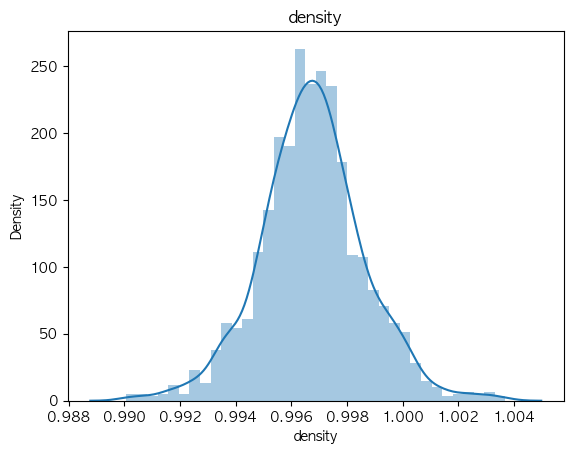

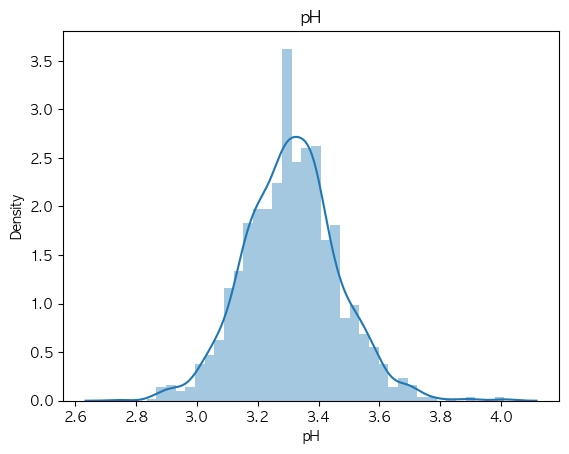

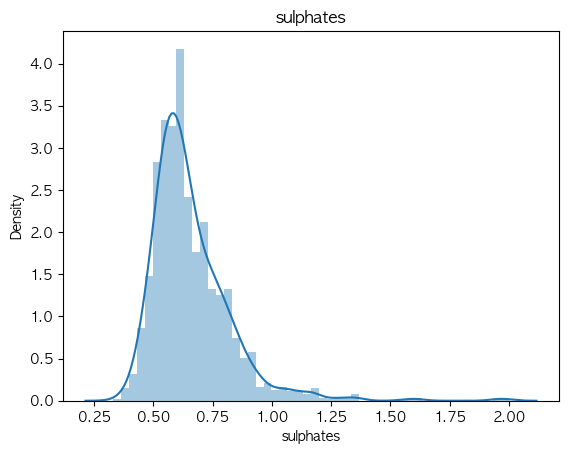

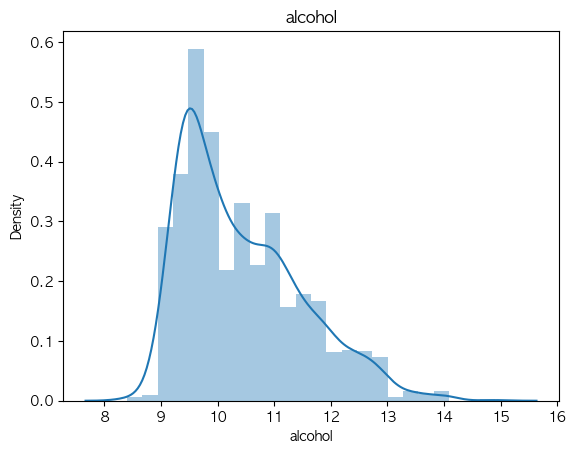

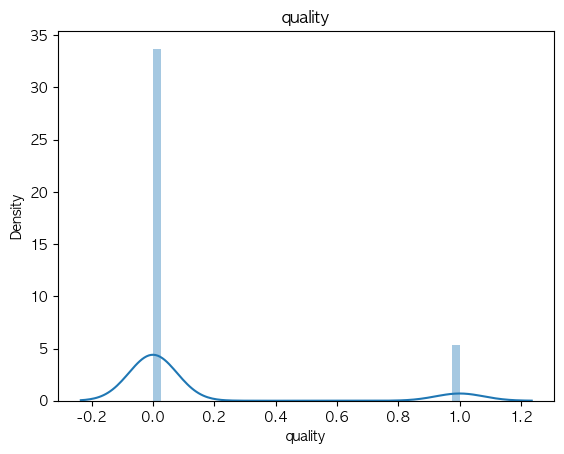

In [88]:
for col in data_modi:
    sns.distplot(data_modi.loc[data[col].notnull(), col])
    plt.title(col)
    plt.show()

quality
0    1382
1     217
Name: count, dtype: int64


<Axes: title={'center': 'class distribution'}, xlabel='count', ylabel='quality'>

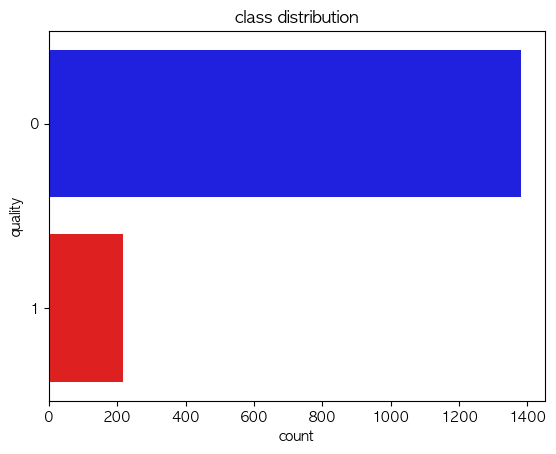

In [89]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data_modi['quality'], data=data_modi, palette=['blue','red'])

# borderline smote 기법을 이용한 Oversampling

In [90]:
from imblearn.over_sampling import BorderlineSMOTE, SMOTE


bsm = BorderlineSMOTE(random_state=42, kind="borderline-1")

In [ ]:
x = data[data.columns.difference(['quality'])]
y = data['quality']

#over_sampled_x , over_sampled_y = bsm.fit_resample(X=x, y=y)

<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

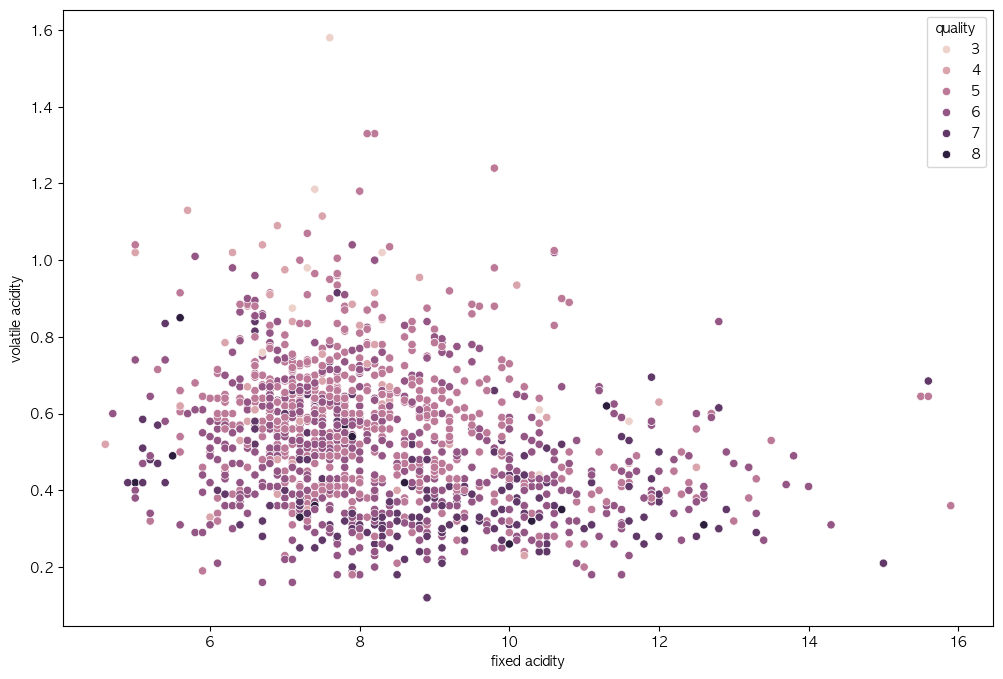

In [64]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue=y, data=x)

In [65]:
# # Unused because Borderline SMOTE is any longer being used

# x_train, x_test, y_train, y_test = train_test_split(over_sampled_x,over_sampled_y, test_size=0.2, random_state=42)
# len(x_test)

In [16]:
y_test.value_counts()

quality
0    310
1    305
Name: count, dtype: int64

In [103]:
# 명목형 변수 : anaemia diabetes high_blood_pressure serum_creatinine sex smoking - 0 or 1
# time : follow-up perioud
x

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
1,9.8,0.098,0.00,0.99680,7.8,25.0,3.20,2.6,0.68,67.0,0.880
2,9.8,0.092,0.04,0.99700,7.8,15.0,3.26,2.3,0.65,54.0,0.760
3,9.8,0.075,0.56,0.99800,11.2,17.0,3.16,1.9,0.58,60.0,0.280
4,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
...,...,...,...,...,...,...,...,...,...,...,...
1594,10.5,0.090,0.08,0.99490,6.2,32.0,3.45,2.0,0.58,44.0,0.600
1595,11.2,0.062,0.10,0.99512,5.9,39.0,3.52,2.2,0.76,51.0,0.550
1596,11.0,0.076,0.13,0.99574,6.3,29.0,3.42,2.3,0.75,40.0,0.510
1597,10.2,0.075,0.12,0.99547,5.9,32.0,3.57,2.0,0.71,44.0,0.645


In [114]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64

In [93]:
# To Avoid modifying downstream code, Just assign original x, y  to over_sample_x(y) variable
over_sampled_x = x
over_sampled_y = y

In [94]:
over_sampled_y[over_sampled_y > 6]

7       7
8       7
16      7
37      7
62      7
       ..
1541    7
1544    7
1549    8
1555    7
1584    7
Name: quality, Length: 217, dtype: int64

In [95]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

over_sampled_y[over_sampled_y <= 6] = 0
over_sampled_y[over_sampled_y > 6] = 1

x_train, x_test, y_train, y_test = train_test_split(over_sampled_x ,over_sampled_y, test_size=0.2, random_state=42)

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_test_sc = pd.DataFrame(x_test_sc,columns=x.columns)
x_train_sc = pd.DataFrame(x_train_sc,columns=x.columns)

# PCA
- std 가 큰 변수에 영향을 받는다 → scaling

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(x_train_sc)

PCA_pred_train = pca.transform(x_train_sc)
result = pca.transform(x_test_sc)
print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.2801769  0.17563995]


In [126]:
result

,feature1,feature2
0,-0.202257,0.568473
1,-1.002544,1.381198
2,1.812686,0.633669
3,0.208948,1.169311
4,-1.348497,-0.585962
...,...,...
315,-1.860115,-0.167971
316,-1.293796,3.298798
317,0.172793,-0.129364
318,0.854692,-1.219958


In [127]:
y_train.value_counts()

quality
0    1109
1     170
Name: count, dtype: int64

In [128]:
y_test.value_counts()

quality
0    273
1     47
Name: count, dtype: int64

In [129]:
y_test_reset_index = y_test.reset_index(drop=True)
y_test_reset_index

0      0
1      0
2      0
3      0
4      0
      ..
315    0
316    0
317    0
318    0
319    0
Name: quality, Length: 320, dtype: int64

In [130]:
result['label'] = y_test_reset_index
result

,feature1,feature2,label
0,-0.202257,0.568473,0
1,-1.002544,1.381198,0
2,1.812686,0.633669,0
3,0.208948,1.169311,0
4,-1.348497,-0.585962,0
...,...,...,...
315,-1.860115,-0.167971,0
316,-1.293796,3.298798,0
317,0.172793,-0.129364,0
318,0.854692,-1.219958,0


In [131]:
result

,feature1,feature2,label
0,-0.202257,0.568473,0
1,-1.002544,1.381198,0
2,1.812686,0.633669,0
3,0.208948,1.169311,0
4,-1.348497,-0.585962,0
...,...,...,...
315,-1.860115,-0.167971,0
316,-1.293796,3.298798,0
317,0.172793,-0.129364,0
318,0.854692,-1.219958,0


In [132]:
result['label'].unique()

array([0, 1])

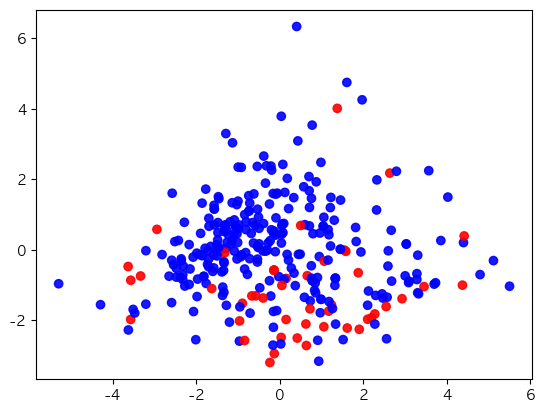

In [133]:
color_map = {0:'blue', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.9)

In [134]:
x_test_sc

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,-0.777453,0.518158,-0.985153,0.175732,-0.361860,-0.181976,-0.465393,-0.038651,-0.000134,-0.019957,0.164286
1,-0.872484,-0.130756,-0.524492,-0.417191,-0.303841,0.497011,0.508915,-0.665729,-1.031438,1.680668,-0.170525
2,-0.492358,0.376208,-0.268569,1.954501,1.378715,0.109019,-0.205577,0.100700,1.833295,-0.384376,0.778108
3,-0.587390,-0.211871,0.192092,0.660851,0.102293,1.563989,0.119192,-0.212839,-0.687670,0.344463,-0.393733
4,0.172862,-0.232149,-0.166200,-1.064016,-0.942051,0.206017,0.508915,-0.596054,-0.343902,-0.384376,-0.393733
...,...,...,...,...,...,...,...,...,...,...,...
315,0.838083,0.700665,-1.394630,-0.751384,-0.884032,-0.084978,0.833684,0.100700,-0.172018,-0.414744,0.610702
316,-0.872484,0.092308,-1.394630,-0.643580,-1.000070,3.406953,-0.725208,1.215505,-1.203322,0.936645,0.554900
317,-0.587390,0.599272,-0.115015,-0.330948,-0.013745,-0.666966,-1.049977,-0.247677,-0.744965,-0.262903,0.387494
318,0.743051,0.234258,0.601569,-0.708262,0.276351,0.400013,-1.049977,-0.387028,0.171750,-0.596954,-1.453971


              precision    recall  f1-score   support

           0      0.863     0.927     0.894       273
           1      0.259     0.149     0.189        47

    accuracy                          0.812       320
   macro avg      0.561     0.538     0.542       320
weighted avg      0.775     0.812     0.790       320



<Axes: >

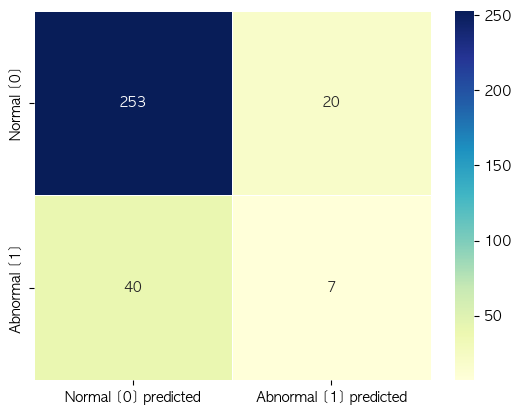

In [135]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제

# x_train 을 통해서 x_proj 를 계산, 이후에 threshold 설정
x_proj = pca.inverse_transform(pca.transform(x_train_sc))
recon_error = ( (x_train_sc - x_proj) **2 ).sum(axis=1)
recon_error = pd.DataFrame(recon_error,columns=['error']).sort_values(by='error',ascending=False)
thre = np.percentile(recon_error, 90)

x_proj = pca.inverse_transform(pca.transform(x_test_sc))
recon_error = ( (x_test_sc - x_proj) **2 ).sum(axis=1)
pred_pca = (recon_error >= thre).astype(int)

print(classification_report(y_test, pred_pca, digits=3))

cm = confusion_matrix(y_test, pred_pca)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KNN

In [136]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier(weights='distance')

In [137]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

print(classification_report(y_test, knn_pred_test, digits=3))

1.0
0.9125
              precision    recall  f1-score   support

           0      0.939     0.960     0.949       273
           1      0.732     0.638     0.682        47

    accuracy                          0.912       320
   macro avg      0.835     0.799     0.816       320
weighted avg      0.909     0.912     0.910       320



[[262  11]
 [ 17  30]]


<Axes: >

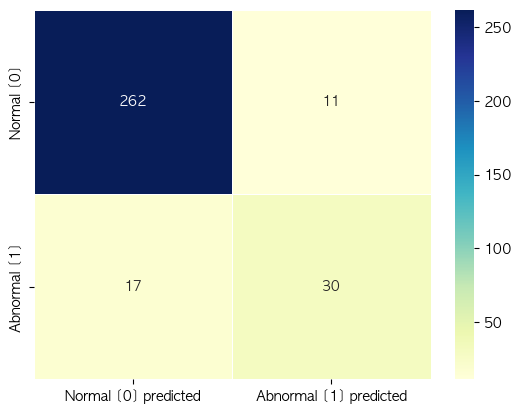

In [138]:
cm = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KMeans

In [139]:
ssd = []
for num in range(2, 11):
    km = KMeans(n_clusters=num, init='k-means++', random_state=42, n_init=10)
    km.fit(x_train_sc)
    ssd.append(km.inertia_)

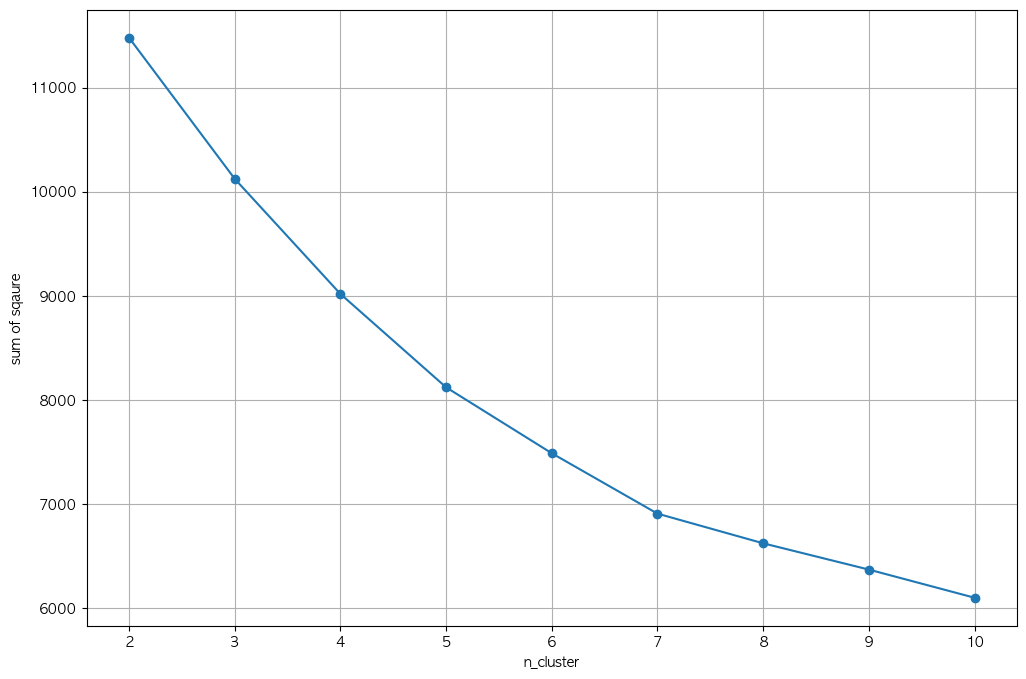

In [140]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11), ssd, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('sum of sqaure')
plt.xticks(range(2,11))
plt.grid()
plt.show()

In [141]:
km = KMeans(n_clusters=5)
km.fit(x_train)

KMeans(n_clusters=5)

In [142]:
def distance_from_center(input_data:pd.DataFrame, predict:pd.DataFrame, y):
    center = km.cluster_centers_[predict]
    dist = ((center-input_data)**2).sum(axis=1) # center 와 input_data 빼고 제곱하고 
    return np.round(dist, 3)

In [143]:
y_pred_train = km.predict(x_train)
dist_train = distance_from_center(x_train, y_pred_train, y_test)

km_x_train = x_train.copy()
km_x_train.loc[:,'pred'] = y_pred_train # 예측 군집 할당
km_x_train.loc[:, 'dist'] = dist_train # 군집 중심과의 거리

y_pred_test = km.predict(x_test)
dist_test = distance_from_center(x_test, y_pred_test, y_test)

km_x_test = x_test.copy()
km_x_test.loc[:,'dist'] = dist_test
km_x_test.loc[:,'pred'] = y_pred_test

In [144]:
# 24개 test data 에 대해 3개 이상치 데이터로 선정
#outlier_idx = list(x_test.sort_values('dist',ascending=False).head(10).index)

# 2nd way, set the threshold
# threshold = np.percentile(x_test['dist'], 90)

threshold = np.percentile(km_x_train['dist'], 90)
print(threshold)

out_lier = km_x_test[km_x_test['dist'] > threshold]

239.9968000000001


In [145]:
out_lier.index

Index([ 247,   23,   32,  184, 1054,  411,  526,  649,  240,  926,  109,  306,
       1389,  678,  905,  711, 1079,  353,  614,   78,  584,   15,  982,  634,
        332, 1529,  670,  425, 1244,  192, 1175, 1295],
      dtype='int64')

In [146]:
y_pred_test = pd.DataFrame(y_pred_test, index=x_test.index)
y_pred_test.loc[out_lier.index] = 1
y_pred_test.loc[out_lier.index]

,0
247,1
23,1
32,1
184,1
1054,1
411,1
526,1
649,1
240,1
926,1


In [147]:
not_out_lier_idx= ~y_pred_test.index.isin(out_lier.index)
y_pred_test.loc[not_out_lier_idx] = 0

In [148]:
print(len(y_pred_test))
print(len(out_lier.index))
print(not_out_lier_idx.sum())

320
32
288


              precision    recall  f1-score   support

           0       0.89      0.85      0.87       288
           1       0.06      0.09      0.08        32

    accuracy                           0.77       320
   macro avg       0.48      0.47      0.47       320
weighted avg       0.81      0.77      0.79       320



<Axes: >

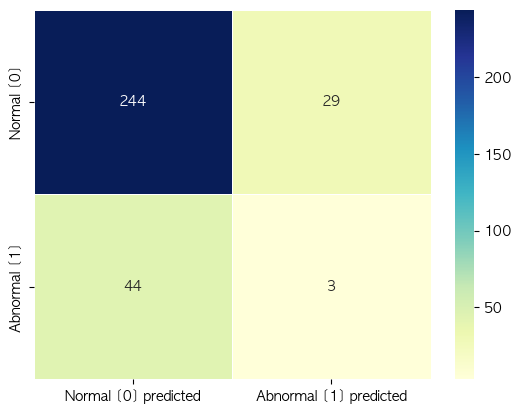

In [149]:
print(classification_report(y_pred_test, y_test))

# dist 가 threshold 보다 큰 outlier 데이터에 대한
# model predict 결과와
# 실제 y_test 
con_mat = confusion_matrix(y_true=y_test, y_pred=y_pred_test)


sns.heatmap(pd.DataFrame(con_mat, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# GMM

- bic 를 통해 모델이 데이터를 얼마나 설명하는가를 판단
- covariance type 을 통해서 공분산 행렬의 형태를 가정 → 이를 통해, mixture 하는 가우시안 분포들이 어떻게 생겼는가를 가정
     - spherical : 모든 공분산이 같은 모양 같은 크기
     - diagonal : 공분산행렬이 대각행렬만 존재, 클러스터의 크기가 다를 수 있음
     - tied : 모양 크기 방향이 같지면 타원형일 수 있음
     - full : 자유자재

In [150]:
from sklearn.mixture import GaussianMixture
best_bic = np.inf
bic = []
cov_type = ["spherical", "diag", "tied", "full"]
n_components_range = range(2,11)

for type in cov_type:
    for n_components in n_components_range:
        mog = GaussianMixture(
            n_components=n_components, covariance_type=type
        )
        mog.fit(x_train)
        bic.append(mog.bic(x_train))
        if bic[-1] < best_bic:
            best_bic = bic[-1]
            best_mog = mog

In [153]:
print(best_mog.covariance_type)
print(best_mog.n_components)

full
5


In [154]:
mog_test_pred = best_mog.predict(x_test)
mog_test_pred = pd.DataFrame(mog_test_pred)
mog_test_pred = mog_test_pred.replace({0:0, 1:0, 2:0, 3:0, 4:1})

mog_train_pred = best_mog.predict(x_train)
mog_train_pred = pd.DataFrame(mog_train_pred)
mog_train_pred = mog_train_pred.replace({0:0, 1:0, 2:0, 3:0, 4:1})

In [155]:
mog_metric = y_train.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_train_pred

# recall
print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1], '\n')

print(len(mog_metric[(mog_metric['quality'] ==0) & (mog_metric['mog_pred'] ==0)]))
print("--")
print(mog_metric['quality'].value_counts()[0])

68
--
170 

919
--
1109


In [156]:
mog_metric = y_test.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_test_pred

print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1])

20
--
47


              precision    recall  f1-score   support

           0      0.894     0.835     0.864       273
           1      0.308     0.426     0.357        47

    accuracy                          0.775       320
   macro avg      0.601     0.630     0.610       320
weighted avg      0.808     0.775     0.789       320



Text(0.5, 23.52222222222222, 'Predicted')

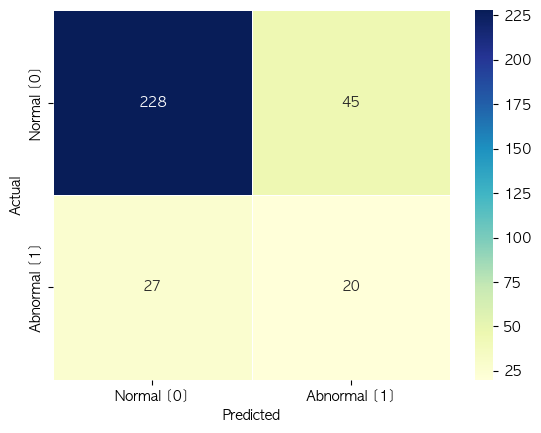

In [157]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print(classification_report(y_true=mog_metric['quality'], y_pred=mog_metric['mog_pred'], digits=3))

con_mat = confusion_matrix(mog_metric['quality'], mog_metric['mog_pred'])

sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# IForest

In [158]:
from sklearn.ensemble import IsolationForest

In [159]:
isol = IsolationForest()
isol.fit(X=x_train, y=y_train)

IsolationForest()

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       273
           1       0.29      0.19      0.23        47

    accuracy                           0.81       320
   macro avg       0.58      0.56      0.56       320
weighted avg       0.78      0.81      0.80       320



Text(0.5, 23.52222222222222, 'Predicted')

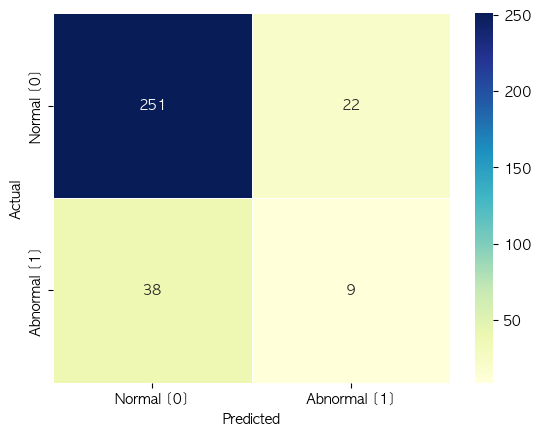

In [160]:
# -1 : anomaly
# 1 : normal
isol_pred_test = isol.predict(x_test)
isol_pred_test = pd.DataFrame(isol_pred_test)
isol_pred_test = isol_pred_test.replace({1:0, -1:1})

print(classification_report(y_true = y_test, y_pred = isol_pred_test))

con_mat = confusion_matrix(y_test, isol_pred_test)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# LoF

In [161]:
from sklearn.neighbors import LocalOutlierFactor

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1382
           1       0.21      0.03      0.06       217

    accuracy                           0.85      1599
   macro avg       0.54      0.51      0.49      1599
weighted avg       0.78      0.85      0.80      1599



Text(0.5, 23.52222222222222, 'Predicted')

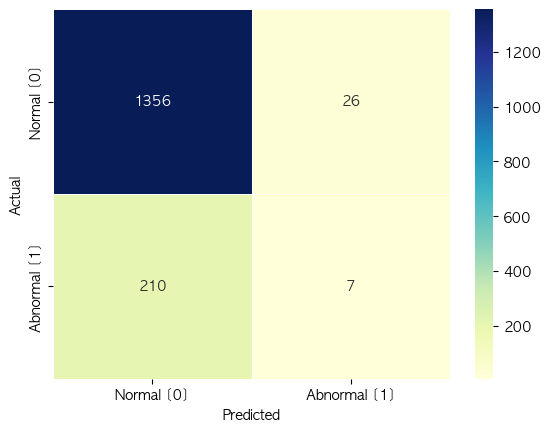

In [162]:
lof = LocalOutlierFactor(novelty=False)

result = lof.fit_predict(X=over_sampled_x, y=over_sampled_y) # y doesnt use in fitting procedure

result = pd.DataFrame(result)
result = result.replace({1:0, -1:1})

print(classification_report(y_true = over_sampled_y, y_pred = result))

con_mat = confusion_matrix(y_true= over_sampled_y, y_pred = result)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Auto Encoder

In [163]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, **kwargs):
        super(AutoEncoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim)
        )
    def forward(self, x):
        x = self.encoder(x)
        out = self.decoder(x)
        return out

class WineDataset(Dataset):
    def __init__(self, input:pd.DataFrame, target:pd.DataFrame):
        self.input = torch.tensor(input.values, dtype=torch.float32)
        self.target = torch.tensor(target.values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.input)
    def __getitem__(self, index):
        return self.input[index], self.target[index]

In [164]:
model_config={
    "input_dim" : len(x_train.columns),
    "batch_size" : 32,
    "lr" : 1e-4,
    "loss" : nn.MSELoss(),
    "epoch" : 250
}

train_dataset = WineDataset(x_train_sc, y_train)
test_dataset = WineDataset(x_test_sc, y_test)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

model = AutoEncoder(input_dim=model_config['input_dim'])

criterion = model_config["loss"]
optimizer = optim.Adam(model.parameters(), lr=model_config["lr"])

In [73]:
device = torch.device('cpu')

train_losses = []
test_losses = []

for epoch in range(model_config['epoch']):
    model.train()
    train_loss = 0
    test_loss = 0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    train_epoch_loss = train_loss / len(train_dataset)
    train_losses.append(train_epoch_loss)
    
    with torch.no_grad():    
        model.eval()
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item() * inputs.size(0)
        test_epoch_loss = test_loss / len(test_dataset)
        test_losses.append(test_epoch_loss)
        
    print(f"Epoch [{epoch+1}/{model_config['epoch']}] completed. [Train] Average Loss: {train_epoch_loss:.4f} , [Test] Average Loss : {test_epoch_loss:.4f}")


Epoch [1/100] completed. [Train] Average Loss: 352.9384 , [Test] Average Loss : 302.1631
Epoch [2/100] completed. [Train] Average Loss: 352.6485 , [Test] Average Loss : 301.8958
Epoch [3/100] completed. [Train] Average Loss: 352.3917 , [Test] Average Loss : 301.6973
Epoch [4/100] completed. [Train] Average Loss: 352.2125 , [Test] Average Loss : 301.5357
Epoch [5/100] completed. [Train] Average Loss: 352.0408 , [Test] Average Loss : 301.3726
Epoch [6/100] completed. [Train] Average Loss: 351.8654 , [Test] Average Loss : 301.2033
Epoch [7/100] completed. [Train] Average Loss: 351.6626 , [Test] Average Loss : 300.9815
Epoch [8/100] completed. [Train] Average Loss: 351.4014 , [Test] Average Loss : 300.7187
Epoch [9/100] completed. [Train] Average Loss: 351.1012 , [Test] Average Loss : 300.4200
Epoch [10/100] completed. [Train] Average Loss: 350.7548 , [Test] Average Loss : 300.0652
Epoch [11/100] completed. [Train] Average Loss: 350.3336 , [Test] Average Loss : 299.6338
Epoch [12/100] comp

In [165]:
from tqdm import tqdm

# recent value 
# \*모든 클래스의 조상인 object 클래스
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0
        self.val = 0
        self.sum = 0
        self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def compute_mse(pred,target):
    pass

In [166]:
def train(model_config, dataset, criterion):
    device = torch.device('cpu')
    train_loader = DataLoader(dataset=dataset[0],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    test_loader = DataLoader(dataset=dataset[1],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    
    model = AutoEncoder(input_dim=model_config['input_dim'])
    model.to(device)
    
    optimizer=optim.Adam(model.parameters(), lr=model_config['lr'])
    
    train_loss, test_loss = AverageMeter(), AverageMeter()
    train_loss_list, test_loss_list = [], []
    best_loss = 0
    
    for epoch in range(1, model_config['epoch']):
        model.train()
        train_bar = tqdm(train_loader) #visualize repeatation part
        train_loss.reset()
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            pred = model(inputs)
            loss = criterion(pred, inputs) # audoencoder calculate loss using inputs & pred
            loss.backward()
            optimizer.step()
            train_loss.update(loss.item(), model_config['batch_size'])
            train_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [train] Loss : {train_loss.avg:.6f}")
        train_loss_list.append(train_loss.avg)
    
        test_bar = tqdm(test_loader)
        test_loss.reset()
    
        for inputs, targets in test_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            model.eval()
            with torch.no_grad():
                pred = model(inputs)
                loss = criterion(pred, inputs)
                test_loss.update(loss.item(), model_config['batch_size'])
                test_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [test] Loss : {test_loss.avg:.6f}")
        test_loss_list.append(test_loss.avg)
    return train_loss_list, test_loss_list

In [167]:
train_loss_list, test_loss_list = train(model_config, [train_dataset, test_dataset], criterion=criterion)

  0%|          | 0/39 [00:00<?, ?it/s]

249/250 [test] Loss : 0.650425: 100%|██████████| 10/10 [00:00<00:00, 912.66it/s]


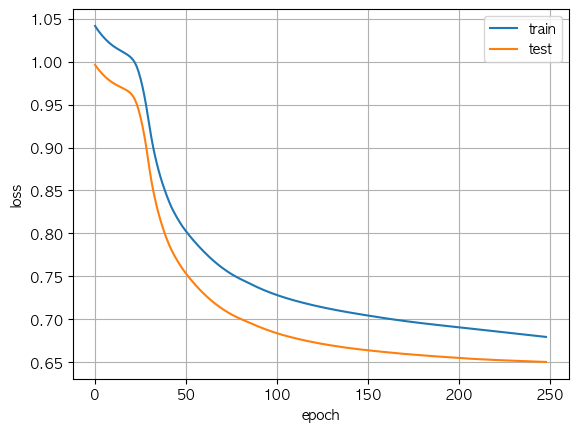

In [168]:
plt.plot(train_loss_list, label='train')
plt.plot(test_loss_list, label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()

In [169]:
model.eval()

ae_train_pred = model(torch.tensor(x_train_sc.values, dtype=torch.float32))

train_mse = np.mean(np.power(ae_train_pred.detach().numpy() - x_train_sc, 2), axis=1)
threshold = np.percentile( sorted(train_mse), 90)

ae_test_pred = model(torch.tensor(x_test_sc.values, dtype=torch.float32))
test_mse = np.mean(np.power(ae_test_pred.detach().numpy() - x_test_sc, 2), axis=1)


              precision    recall  f1-score   support

           0       0.85      0.89      0.87       273
           1       0.09      0.06      0.08        47

    accuracy                           0.77       320
   macro avg       0.47      0.48      0.47       320
weighted avg       0.74      0.77      0.75       320



<Axes: >

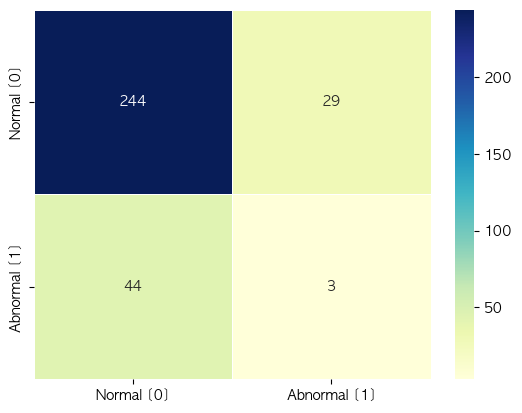

In [170]:
outlier_idx = test_mse[test_mse > threshold].index
ae_y_pred = y_test.copy()
ae_y_pred = pd.DataFrame(ae_y_pred)
ae_y_pred['pred'] = 0
ae_y_pred.loc[out_lier.index, 'pred'] = 1

print(classification_report(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred']))

con_mat = confusion_matrix(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred'])
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# My pick : One class SVM

In [96]:
print(y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.2, random_state=42)

quality
0    1382
1     217
Name: count, dtype: int64


In [129]:
from sklearn.svm import OneClassSVM

sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

oc_svm = OneClassSVM(kernel='rbf', nu=0.2)
oc_svm.fit(x_train_sc)

y_pred_svm = oc_svm.predict(x_test_sc) # 정상 1, 이상치 -1


In [130]:
y_pred_svm[y_pred_svm == 1] = 0
y_pred_svm[y_pred_svm == -1] = 1
y_pred_svm

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,

              precision    recall  f1-score   support

           0      0.866     0.806     0.835       273
           1      0.197     0.277     0.230        47

    accuracy                          0.728       320
   macro avg      0.532     0.541     0.533       320
weighted avg      0.768     0.728     0.746       320



Text(50.722222222222214, 0.5, 'actual')

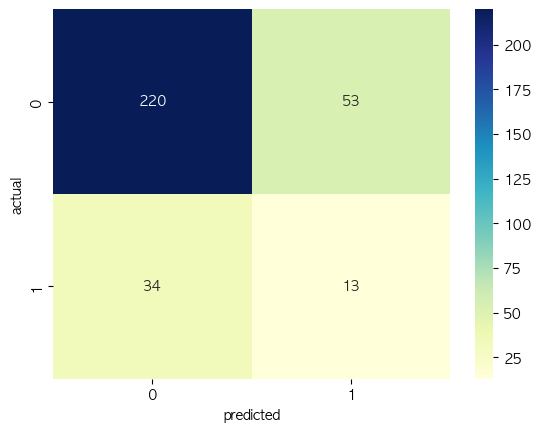

In [131]:
print(classification_report(y_true = y_test, y_pred=y_pred_svm, digits=3))

con_mat = confusion_matrix(y_true = y_test, y_pred=y_pred_svm)

sns.heatmap(con_mat, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')

In [ ]:
con_mat # row : actual , col : predicted

array([[195,  78],
       [ 28,  19]])